In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
data = pd.read_csv("segmentation data.csv")

In [54]:
data.shape

(2000, 7)

In [55]:
data.head()

,Gender,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [57]:
scaled_data= pd.DataFrame(scaled_data, columns=scaler.feature_names_in_)
scaled_data

,Gender,Marital status,Age,Education,Income,Occupation,Settlement size
0,-0.917399,-0.993024,2.653614,1.604323,0.097524,0.296823,1.552326
1,1.090038,1.007025,-1.187132,-0.063372,0.782654,0.296823,1.552326
2,-0.917399,-0.993024,1.117316,-0.063372,-0.833202,-1.269525,-0.909730
3,-0.917399,-0.993024,0.775916,-0.063372,1.328386,0.296823,0.321298
4,-0.917399,-0.993024,1.458716,-0.063372,0.736932,0.296823,0.321298
...,...,...,...,...,...,...,...
1995,1.090038,-0.993024,0.946616,-0.063372,0.067471,-1.269525,-0.909730
1996,1.090038,1.007025,-0.760382,-0.063372,-0.084265,0.296823,-0.909730
1997,-0.917399,-0.993024,-0.418983,-1.731068,-0.906957,-1.269525,-0.909730
1998,1.090038,1.007025,-1.016432,-0.063372,-0.603329,-1.269525,-0.909730


In [58]:
from sklearn.cluster import KMeans

In [59]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(scaled_data)

KMeans(n_clusters=4)

In [60]:
cluster = kmeans.predict(scaled_data)

In [61]:
kmeans.inertia_

7169.911569137166

In [62]:
wcss  = []
for cluster in range(1,10):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)


frame = pd.DataFrame({'Cluster':range(1,10), 'wcss':wcss})
frame

,Cluster,wcss
0,1,14000.000000
1,2,10674.304250
2,3,8631.672548
3,4,7169.911569
4,5,6692.411914
5,6,5921.824144
6,7,5572.252395
7,8,5190.249722
8,9,4922.693831


Text(0, 0.5, 'Inertia')

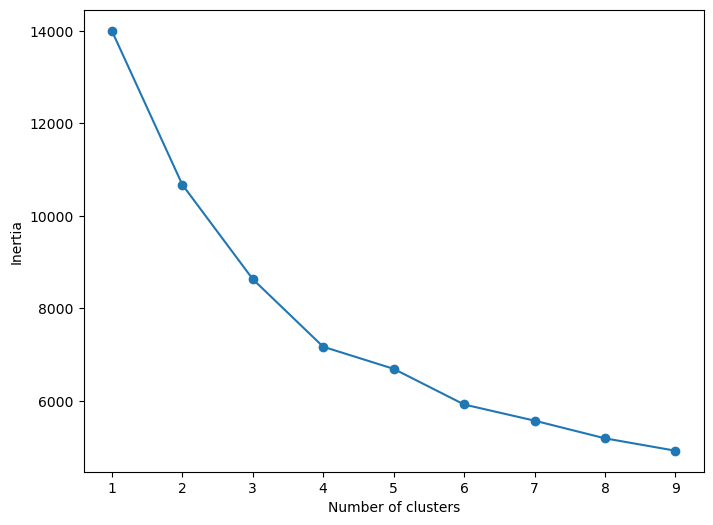

In [63]:
plt.figure(figsize=(8,6))
plt.plot(frame['Cluster'], frame['wcss'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [64]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(scaled_data)
cluster = kmeans.predict(scaled_data)

In [65]:
data['cluster'] = cluster

In [66]:
data

,Gender,Marital status,Age,Education,Income,Occupation,Settlement size,cluster
0,0,0,67,2,124670,1,2,0
1,1,1,22,1,150773,1,2,3
2,0,0,49,1,89210,0,0,1
3,0,0,45,1,171565,1,1,2
4,0,0,53,1,149031,1,1,2
...,...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0,1
1996,1,1,27,1,117744,1,0,3
1997,0,0,31,0,86400,0,0,1
1998,1,1,24,1,97968,0,0,3


In [67]:
data.cluster.unique()

array([0, 3, 1, 2])

In [68]:
data.cluster.value_counts()

cluster
3    705
2    570
1    461
0    264
Name: count, dtype: int64

In [70]:
cluster_groups = data.groupby('cluster')

In [85]:
group_0 = cluster_groups.get_group(0)
group_1 = cluster_groups.get_group(1)
group_2 = cluster_groups.get_group(2)
group_3 = cluster_groups.get_group(3)

In [86]:
group_0.Age.mean(), group_0.Income.mean(), group_0.Income.std()

(55.68939393939394, 158209.0946969697, 46164.59427052403)

In [87]:
group_1.Age.mean(), group_1.Income.mean(), group_1.Income.std()

(35.54229934924078, 97802.72451193059, 22942.862325123973)

In [88]:
group_2.Age.mean(), group_2.Income.mean(), group_2.Income.std()

(35.63508771929825, 141218.24912280703, 33459.29968562953)

In [89]:
group_3.Age.mean(), group_3.Income.mean(), group_3.Income.std()

(28.963120567375885, 105759.11914893617, 25370.288130989353)

In [ ]:
group0: higher age with income higher  : potential
group1: middle age with income avergae : 